# VarQITE — Portfolio Optimization (QAOA X-Mixer Ansatz)

Variational Quantum Imaginary Time Evolution via McLachlan's variational principle ([arXiv:1804.03023](https://arxiv.org/pdf/1804.03023))

Fundemental derivation of the McLachlan's variational principle and further Fubini-Studey phase correction (eq.13-14 [arXiv:1812.08767](https://arxiv.org/pdf/1812.08767))


$\frac{d|\psi(\tau)\rangle}{d\tau} = -(H - E_\tau)|\psi(\tau)\rangle$

$\sum_j A_{ij}\dot{\theta}_j = C_i \quad\Rightarrow\quad \theta \leftarrow \theta + \delta\tau\, A^{-1}C$

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cudaq
import sys
import os
import time
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from math import sqrt
from tqdm import tqdm
from typing import List, Tuple
sys.path.append(os.path.abspath(".."))
from Utils.qaoaCUDAQ import po_normalize, ret_cov_to_QUBO, qubo_to_ising, process_ansatz_values, kernel_qaoa_X, all_state_to_return, find_budget, to_sig

pd.set_option("display.width", 1000)

# Hyperparameters

INIT $\in$ {Zero, Random, Ramp}

OPTIMIZE_METHOD $\in$ {gradient, mcLachlan, ramp}

INVERSE_METHOD $\in$ {diagonalize, tikhonov} (mcLachlan only)

PHASE_CORRECTION $\in$ {True, False} (mcLachlan only)

RAMP_DELTA_GAMMA, RAMP_DELTA_BETA, RAMP_SIGN $\in$ {-1, 1}, RAMP_GAMMA_UNITS $\in$ {boosted, circuit}, RAMP_LAYERS (ramp only)

In [ ]:
e = 0
SEED = 0
N_ASSETS = 7
TARGET_QUBIT_IN = 2
q = 1.5
lamb = 0.005
LAYER = 5
eps = 0.1

INIT = "Ramp"
DELTA_GAMMA = 3.0
DELTA_BETA = 1.5
RAMP_DELTA_GAMMA = 3.0         # ramp (rampB) only: schedule amplitudes in boosted cost units, grid-tuned on exp 0 at p=200
RAMP_DELTA_BETA = 0.2
RAMP_SIGN = -1                 # kernel_qaoa_X anneals to max(H) with +beta from |+>, so the ramp state negates beta
RAMP_GAMMA_UNITS = "boosted"   # "boosted" = gamma * hamiltonian_boost (rampB); "circuit" = gamma as is (PO_new_ApproxRatio.py mode "Ramp")
RAMP_LAYERS = [50, 100, 200]   # layer counts of the linear-ramp scan

# OPTIMIZE_METHOD = "mcLachlan"
OPTIMIZE_METHOD = "gradient"

DTAU = 0.1
N_STEPS = 300
FD_SHIFT = 1e-4
ANALYTIC_DERIV = True
PHASE_CORRECTION = True
# INVERSE_METHOD = "diagonalize"
INVERSE_METHOD = "tikhonov"
TIKHONOV_LAMBDA = 1e-8
EIG_CUTOFF = 1e-12

MAX_ITER = 300
LR = 0.01
SHIFT = 1e-4
WEIGHT_DECAY = 0.0

F_TOL = 1e-4
HAM_BOOST_MODE = "Jh"
HAM_BOOST = 1.0
PRECISION = "fp64"

min_P, max_P = 108, 216
DUPLICATE_ASSET = False

OVERWRITE = False

assert INIT in ["Zero", "Random", "Ramp"]
assert OPTIMIZE_METHOD in ["gradient", "mcLachlan", "ramp"]
assert RAMP_SIGN in [-1, 1] and RAMP_GAMMA_UNITS in ["circuit", "boosted"]
assert INVERSE_METHOD in ["diagonalize", "tikhonov"]
assert HAM_BOOST_MODE in ["J", "Jh", "h", "fixed"]

if PRECISION == "fp64":
    cudaq.set_target("nvidia", option="fp64")
else:
    cudaq.set_target("nvidia")
device = torch.device("cuda:0")
torch_cdtype = torch.complex128 if PRECISION == "fp64" else torch.complex64
torch_rdtype = torch.float64 if PRECISION == "fp64" else torch.float32

# Dataset

In [51]:
data_cov_pd = pd.read_csv("../dataset/top_50_us_stocks_data_20250526_011226_covariance.csv")
data_ret_p_pd = pd.read_csv("../dataset/top_50_us_stocks_returns_price.csv")

data_ret_p_pd = data_ret_p_pd[(data_ret_p_pd["Price"] > min_P) & (data_ret_p_pd["Price"] < max_P)]
data_cov_pd = data_cov_pd.loc[data_cov_pd["Ticker"].isin(data_ret_p_pd["Ticker"])].reset_index(drop=True)
data_cov_pd = data_cov_pd[["Ticker"] + data_cov_pd["Ticker"].tolist()]

In [52]:
st = time.perf_counter()
np.random.seed(911 + 991 * e + 997 * N_ASSETS)
rng_state = np.random.get_state()
asset_idx = np.random.choice(data_cov_pd.shape[0], N_ASSETS, replace=DUPLICATE_ASSET)
data_cov = data_cov_pd.drop("Ticker", axis=1).to_numpy()[asset_idx, :][:, asset_idx]
stock_names = data_ret_p_pd["Company_Name"].to_numpy()[asset_idx]
data_ret_p = data_ret_p_pd.drop("Ticker", axis=1)
asset_idx_raw = data_ret_p.index[asset_idx].to_numpy()
data_ret_p = data_ret_p.drop("Company_Name", axis=1).to_numpy()[asset_idx, :]
data_ret = data_ret_p[:, 0]
data_p = data_ret_p[:, 1]

np.random.set_state(rng_state)
weighted = np.random.uniform(0, 1)
B_mi, B_ma = find_budget(TARGET_QUBIT_IN * N_ASSETS, data_p, min_P, max_P, min_mix_mode=True)
B = B_mi * weighted + B_ma * (1 - weighted)
data_time = time.perf_counter() - st

print("Selected Stocks:", stock_names)
print("Prices:", data_p)
print("Returns:", data_ret)
print("Budget:", B)

Selected Stocks: ['Danaher Corporation' 'Texas Instruments Incorporated' 'Alphabet Inc.'
 'PepsiCo, Inc.' 'Philip Morris International Inc.' 'RTX Corporation'
 'NVIDIA Corporation']
Prices: [205.         178.17987061 156.22999573 149.94000244 158.72999573
 131.78817749 108.37999725]
Returns: [0.00086961 0.00072521 0.00085885 0.0003658  0.00060737 0.00047252
 0.00261817]
Budget: 429.10274016532094


# Hamiltonians

$
\begin{aligned}
H &= \lambda I - \sum_{i,j} \text{QU}_{ij} \left(\frac{1-Z_i}{2}\right)\otimes\left(\frac{1-Z_j}{2}\right) \\
&= nI + \sum_i h_i Z_i + \sum_{ij} J_{ij} Z_i Z_j
\end{aligned}
$

Note that $QU$ is a max problem, while $H$ is now a min problem.

One way to normalize the Hamiltonian is:
$
H_\text{norm} = \frac{H - \lambda I}{\|H - \lambda I\|_F}
$

In [53]:
st = time.perf_counter()
P = data_p[:N_ASSETS]
ret = data_ret[:N_ASSETS]
cov = data_cov[:N_ASSETS, :N_ASSETS]
P_bb, ret_bb, cov_bb, n_qubit, n_max, C_enc = po_normalize(B, P, ret, cov)
TARGET_QUBIT = n_qubit

QU = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, lamb, q)
QU_lamb = ret_cov_to_QUBO(np.zeros_like(ret_bb), np.zeros_like(cov_bb), P_bb, lamb, 0.0)
QU_eval = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, 0.0, q)
QU_return = ret_cov_to_QUBO(ret_bb, np.zeros_like(cov_bb), np.zeros_like(P_bb), 0.0, 0.0)
QU_risk = ret_cov_to_QUBO(np.zeros_like(ret_bb), cov_bb, np.zeros_like(P_bb), 0.0, q)

H_ansatz = -qubo_to_ising(QU, lamb).canonicalize()
idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use = process_ansatz_values(H_ansatz)
coeff_1_use, coeff_2_use = np.array(coeff_1_use), np.array(coeff_2_use)

max_J = np.max(np.abs(coeff_2_use))
max_h = np.max(np.abs(coeff_1_use))
max_J_h = max(max_J, max_h)
use_norm = max_J if HAM_BOOST_MODE == "J" else max_J_h if HAM_BOOST_MODE == "Jh" else max_h if HAM_BOOST_MODE == "h" else 1.0
hamiltonian_boost = to_sig(1 / use_norm if HAM_BOOST_MODE != "fixed" else HAM_BOOST, 4)
H_ansatz = H_ansatz * hamiltonian_boost
ham_time = time.perf_counter() - st

print("Qubits:", n_qubit)
print("hamiltonian_boost:", hamiltonian_boost)
print("terms: h =", len(coeff_1_use), ", J =", len(coeff_2_use))

Qubits: 14
hamiltonian_boost: 72.27
terms: h = 14 , J = 91


# Exact Reference

$H$ is diagonal in the computational basis, so $\mathrm{diag}(H)$, the exact ground state, and $H|\psi\rangle$ come from the classical energy table (no `to_matrix` / `eigh` needed)

In [54]:
st = time.perf_counter()
state_eval = all_state_to_return(n_qubit, 0.0, QU_eval)
state_optim = -all_state_to_return(n_qubit, lamb, QU)
state_penalty = -all_state_to_return(n_qubit, lamb, QU_lamb)
state_return = all_state_to_return(n_qubit, 0.0, QU_return)
state_risk = -all_state_to_return(n_qubit, 0.0, QU_risk)
diag_H = hamiltonian_boost * state_optim.astype(np.float64)

order = np.argsort(state_optim)
E0, E1 = diag_H[order[0]], diag_H[order[1]]
idx_ground = np.where(np.isclose(state_optim, state_optim[order[0]]))[0]
idx_optimal = int(np.argsort(state_eval)[-1])

eps_t = lamb * eps ** 2
idx_feasible = np.where(np.abs(state_penalty) <= eps_t)[0]
mi_r, ma_r = (state_eval[idx_feasible].min(), state_eval[idx_feasible].max()) if len(idx_feasible) >= 2 else (np.nan, np.nan)
exact_time = time.perf_counter() - st

print("E0:", E0, "| E1:", E1, "| spectral gap:", E1 - E0)
print("ground state(s):", [bin(i)[2:].zfill(n_qubit) for i in idx_ground])
print("optimal (eval) state:", bin(idx_optimal)[2:].zfill(n_qubit), "| is ground:", idx_optimal in set(idx_ground.tolist()))
print("feasible states:", len(idx_feasible), "| eval range:", (mi_r, ma_r))

E0: -0.0857185184086154 | E1: -0.08208971764997762 | spectral gap: 0.003628800758637779
ground state(s): ['00000000100011']
optimal (eval) state: 10000000100011 | is ground: False
feasible states: 44 | eval range: (np.float64(7.061217938941166e-05), np.float64(0.001156900200384208))


# Ansatz & Initial Parameters

In [55]:
layer_count = LAYER
parameter_count = 2 * layer_count
ansatz_fixed_param = (int(n_qubit), layer_count, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use)

mm_1 = np.min(np.abs(coeff_1_use)) if len(coeff_1_use) > 0 else 1e9
mm_2 = np.min(np.abs(coeff_2_use)) if len(coeff_2_use) > 0 else 1e9
mm_i = np.pi / min(mm_1, mm_2)

def make_points_init(init=None):
    init = INIT if init is None else init
    np.random.seed(4001 + 4099 * e + 4999 * N_ASSETS + 5099 * SEED)
    points = np.zeros(parameter_count)
    if init == "Random":
        points = np.random.uniform(-1, 1, parameter_count)
        points[:layer_count] *= mm_i
        points[layer_count:] *= np.pi
    elif init == "Ramp":
        for i in range(layer_count):
            points[i] = DELTA_GAMMA * (i + 1) / layer_count
            points[layer_count + i] = DELTA_BETA * (1 - i / layer_count)
    return points

points_init = make_points_init()
print("initial parameters:", np.round(points_init, 4).tolist())


initial parameters: [0.6, 1.2, 1.8, 2.4, 3.0, 1.5, 1.2, 0.9, 0.6, 0.3]


In [56]:
axes_flip = tuple(range(n_qubit - 1, -1, -1))
dim = 1 << n_qubit

def get_psi_p(params, p):
    psi = np.array(cudaq.get_state(kernel_qaoa_X, params, int(n_qubit), int(p), idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use))
    return psi.reshape([2] * n_qubit).transpose(axes_flip).ravel().astype(np.complex128)

def get_psi(params):
    return get_psi_p(params, layer_count)

def metrics(psi):
    prob = np.abs(psi) ** 2
    E_obj = float(prob @ state_optim)
    E_eval = float(-(prob @ state_eval))
    E_lamb = float(prob @ state_penalty)
    P_ground = float(prob[idx_ground].sum())
    P_optimal = float(prob[idx_optimal])
    approx_ratio = (float(prob @ state_eval) - mi_r) / (ma_r - mi_r) if len(idx_feasible) >= 2 else float("nan")
    return E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio

psi0 = get_psi(points_init)
print("energy via diag_H: ", float(np.real(np.vdot(psi0, diag_H * psi0))))
print("energy via observe:", float(cudaq.observe(kernel_qaoa_X, H_ansatz, points_init, *ansatz_fixed_param).expectation()))

energy via diag_H:  3.816705538525023
energy via observe: 3.816705538525023


# McLachlan VarQITE

Note that
$
\partial_i\langle\phi|\phi\rangle = \langle\partial_i\phi|\phi\rangle + \langle\phi|\partial_i\phi\rangle = 0 \;
\Rightarrow\;
\langle\partial_i\phi|\phi\rangle = -\langle\phi|\partial_i\phi\rangle,
$

$
\begin{aligned}
A_{ij} &= \mathrm{Re}\big(\langle\partial_i\psi|\partial_j\psi\rangle\big) + \mathrm{Re}\big(\langle\partial_i\psi|\psi\rangle\langle\partial_j\psi|\psi\rangle\big) \\ &= \mathrm{Re}\big(\langle\partial_i\psi|\partial_j\psi\rangle\big) - \underbrace{\mathrm{Re}\big(\langle\partial_i\psi|\psi\rangle\langle\psi|\partial_j\psi\rangle\big)}_{\text{PHASE\_CORRECTION}}
\end{aligned}
$


$C_i = -\mathrm{Re}\big(\langle\partial_i\psi|H|\psi\rangle\big)$

diagonalize: $A = V\Lambda V^T$, drop $\lambda_k \le \text{EIG\_CUTOFF}\cdot\lambda_{\max}$, then $\dot\theta = V\Lambda^{+}V^T C$

tikhonov: $\dot\theta = (A + \lambda_{tik} I)^{-1} C$


# Analytic Differential

Let $|\psi(\beta,\gamma)\rangle = M(\beta_p)C(\gamma_p)\cdots M(\beta_1)C(\gamma_1)|+\rangle^{\otimes n}$ ,where

$
\begin{aligned}
C(\gamma) &= \exp\left(-i \gamma H_C\right) \\
M(\beta) &= \exp\left(-i \beta H_M\right)
\end{aligned}
$


In [ ]:
def dpsi_all_fd(params):
    dps = np.zeros((parameter_count, dim), dtype=np.complex128)
    for i in range(parameter_count):
        pp, pm = params.copy(), params.copy()
        pp[i] += FD_SHIFT
        pm[i] -= FD_SHIFT
        dps[i] = (get_psi(pp) - get_psi(pm)) / (2 * FD_SHIFT)
    return dps

d_gamma = np.zeros(dim)
bits = np.arange(dim)
for j in range(len(idx_1_use)):
    d_gamma += coeff_1_use[j] * (1 - 2 * ((bits >> (n_qubit - 1 - idx_1_use[j])) & 1))
for j in range(len(idx_2_a_use)):
    z_a = 1 - 2 * ((bits >> (n_qubit - 1 - idx_2_a_use[j])) & 1)
    z_b = 1 - 2 * ((bits >> (n_qubit - 1 - idx_2_b_use[j])) & 1)
    d_gamma += coeff_2_use[j] * z_a * z_b
d_gamma_t = torch.tensor(d_gamma, device=device, dtype=torch_rdtype)

def apply_cost(v, gamma):
    return torch.exp(-1j * gamma * d_gamma_t) * v

def apply_mixer(v, beta):
    c, s = float(np.cos(beta)), float(np.sin(beta))
    for j in range(n_qubit):
        vv = v.reshape([2] * n_qubit)
        v = (c * vv - 1j * s * torch.flip(vv, dims=[j])).reshape(-1)
    return v

def apply_H_X(v):
    vv = v.reshape([2] * n_qubit)
    out = torch.zeros_like(v)
    for j in range(n_qubit):
        out += torch.flip(vv, dims=[j]).reshape(-1)
    return out

def psi_analytic(params):
    v = torch.full((dim,), 1 / sqrt(dim), device=device, dtype=torch_cdtype)
    for l in range(layer_count):
        v = apply_mixer(apply_cost(v, params[l]), params[layer_count + l])
    return v.cpu().numpy().astype(np.complex128)

def dpsi_all_analytic(params):
    gammas, betas = params[:layer_count], params[layer_count:]
    s = torch.full((dim,), 1 / sqrt(dim), device=device, dtype=torch_cdtype)
    states_a, states_s = [], []
    for l in range(layer_count):
        a = apply_cost(s, gammas[l])
        states_a.append(a)
        s = apply_mixer(a, betas[l])
        states_s.append(s)
    dps = torch.zeros((parameter_count, dim), device=device, dtype=torch_cdtype)
    for l in range(layer_count):
        w = apply_mixer(-1j * d_gamma_t * states_a[l], betas[l])
        for m in range(l + 1, layer_count):
            w = apply_mixer(apply_cost(w, gammas[m]), betas[m])
        dps[l] = w
        w = -1j * apply_H_X(states_s[l])
        for m in range(l + 1, layer_count):
            w = apply_mixer(apply_cost(w, gammas[m]), betas[m])
        dps[layer_count + l] = w
    return dps.cpu().numpy().astype(np.complex128)

def dpsi_all(params):
    return dpsi_all_analytic(params) if ANALYTIC_DERIV else dpsi_all_fd(params)

def build_A_C(psi, dps, phase_correction=None):
    phase_correction = PHASE_CORRECTION if phase_correction is None else phase_correction
    A = np.real(dps.conj() @ dps.T)
    if phase_correction:
        v = dps.conj() @ psi
        A -= np.real(np.outer(v, v.conj()))
    C = -np.real(dps.conj() @ (diag_H * psi))
    return A, C

def solve_theta_dot(A, C, inverse=None):
    inverse = INVERSE_METHOD if inverse is None else inverse
    if inverse == "diagonalize":
        w, V = np.linalg.eigh(A)
        w_inv = np.zeros_like(w)
        keep = w > EIG_CUTOFF * np.max(np.abs(w))
        w_inv[keep] = 1.0 / w[keep]
        return V @ (w_inv * (V.T @ C))
    return np.linalg.solve(A + TIKHONOV_LAMBDA * np.eye(parameter_count), C)

In [58]:
print("max |analytic psi - cudaq psi|:", np.abs(psi_analytic(points_init) - get_psi(points_init)).max())
print("max |analytic dpsi - FD dpsi| :", np.abs(dpsi_all_analytic(points_init) - dpsi_all_fd(points_init)).max())

for f, name in [(dpsi_all_fd, "FD      "), (dpsi_all_analytic, "analytic")]:
    f(points_init)
    st = time.perf_counter()
    for _ in range(5):
        f(points_init)
    print(f"{name} dpsi: {(time.perf_counter() - st) / 5 * 1e3:.2f} ms")

max |analytic psi - cudaq psi|: 3.373803031874027e-17
max |analytic dpsi - FD dpsi| : 5.982698893118115e-08
FD       dpsi: 162.61 ms
analytic dpsi: 7.96 ms


In [59]:
def optimize_mcLachlan(params_init, inverse=None, phase_correction=None, pbar=True):
    inverse = INVERSE_METHOD if inverse is None else inverse
    phase_correction = PHASE_CORRECTION if phase_correction is None else phase_correction
    params = params_init.copy()
    history, iter_times = [], []
    last_f, cou_con, num_iter = None, 0, 0
    psi = get_psi(params)
    pbar_it = tqdm(range(N_STEPS), disable=not pbar)
    for it in pbar_it:
        st_it = time.perf_counter()
        dps = dpsi_all(params)
        A, C = build_A_C(psi, dps, phase_correction)
        theta_dot = solve_theta_dot(A, C, inverse)
        params += DTAU * theta_dot
        psi = get_psi(params)
        iter_times.append(time.perf_counter() - st_it)
        E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio = metrics(psi)
        history.append([E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio, params[0], params[layer_count]])
        num_iter += 1
        expectation = E_obj * hamiltonian_boost
        cou_con = cou_con + 1 if last_f is not None and abs(expectation - last_f) < F_TOL else 0
        if cou_con >= 3:
            break
        last_f = expectation
        if pbar:
            pbar_it.set_description(f"E {E_obj:.6f}, E_eval {E_eval:.6f}, P_gs {P_ground:.4f}")
    return params, np.array(history), np.array(iter_times), num_iter


# Gradient (old method)

Adam(lr=LR, betas=(0.95, 0.98)) + CosineAnnealingLR + forward-difference gradient of $\langle H\rangle$, as in PO_new_ApproxRatio.py

In [60]:
def optimize_gradient(params_init, pbar=True):
    points_cu = torch.tensor(params_init, dtype=torch.float64, device=device)
    optimizer_cu = Adam([points_cu], lr=LR, betas=(0.95, 0.98), weight_decay=WEIGHT_DECAY, decoupled_weight_decay=True)
    scheduler = CosineAnnealingLR(optimizer_cu, T_max=MAX_ITER, eta_min=0.0003)
    history, iter_times = [], []
    last_f, cou_con, num_iter = None, 0, 0
    pbar_it = tqdm(range(MAX_ITER), disable=not pbar)
    for it in pbar_it:
        st_it = time.perf_counter()
        optimizer_cu.zero_grad()
        params = points_cu.detach().cpu().numpy()
        expectation = float(cudaq.observe(kernel_qaoa_X, H_ansatz, params, *ansatz_fixed_param).expectation())
        grad = torch.zeros(parameter_count, dtype=torch.float64, device=device)
        for j in range(parameter_count):
            shift = np.zeros(parameter_count)
            shift[j] = SHIFT
            forward = float(cudaq.observe(kernel_qaoa_X, H_ansatz, params + shift, *ansatz_fixed_param).expectation())
            grad[j] = (forward - expectation) / SHIFT
        points_cu.grad = grad
        optimizer_cu.step()
        scheduler.step()
        iter_times.append(time.perf_counter() - st_it)
        E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio = metrics(get_psi(params))
        history.append([E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio, points_cu[0].item(), points_cu[layer_count].item()])
        num_iter += 1
        cou_con = cou_con + 1 if last_f is not None and abs(expectation - last_f) < F_TOL else 0
        if cou_con >= 3:
            break
        last_f = expectation
        if pbar:
            pbar_it.set_description(f"E {E_obj:.6f}, E_eval {E_eval:.6f}, P_gs {P_ground:.4f}, LR {optimizer_cu.param_groups[0]['lr']:.4f}")
    return points_cu.detach().cpu().numpy(), np.array(history), np.array(iter_times), num_iter

# Linear Ramp (rampB, no optimization)

LR-QAOA / discretized-annealing baseline: the schedule
$\gamma_i = \Delta_\gamma\, b\, \frac{i+1}{p},\qquad \beta_i = s\,\Delta_\beta \left(1 - \frac{i}{p}\right)$
is evaluated once with a single circuit, no parameter update (`epochs = 0`). Same form as `PO_new_ApproxRatio.py` mode `"Ramp"`, with two changes that make it anneal on this kernel:

- **Sign** `RAMP_SIGN` $s = -1$: `kernel_qaoa_X` applies $e^{-i\beta X}$ to $|+\rangle$, the top eigenstate of $+\sum_j X_j$, so a positive ramp anneals to $\max H$; negating $\beta$ anneals to the ground state.
- **Units** `RAMP_GAMMA_UNITS = "boosted"`: $\gamma$ is given in *boosted* cost units, i.e. multiplied by the boost $b =$ `hamiltonian_boost` (defined below). The circuit carries the unboosted coefficients ($c_{\max} = 1/b \approx 0.014$ here), so $\gamma$ in circuit units rotates the cost by $\lesssim 0.04$ rad per layer and the paper's $(\Delta_\beta, \Delta_\gamma) = (1.5, 3)$ never leaves $|+\rangle$. In boosted units $\Delta_\gamma$ counts rotations of the normalized cost ($c_{\max} = 1$); $(\Delta_\beta, \Delta_\gamma) = (0.2, 3.0)$ (`RAMP_DELTA_BETA`, `RAMP_DELTA_GAMMA`, grid-tuned on exp 0 at $p = 200$) is within 10% of the optimum for $\lambda \in \{0.0005, 0.005, 0.05\}$.

**Definition of the boost $b$ (`hamiltonian_boost`, computed in the *Hamiltonians* cell).** Write the problem operator in its *unboosted* Ising form,

$$
H^{\rm unb} = \lambda I - \sum_{i,j} \mathrm{QU}_{ij}\, x_i x_j
= n\,I + \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j ,
\qquad x_i = \frac{I - Z_i}{2} ,
$$

$$
h_i = \tfrac{1}{2}\sum_j \mathrm{QU}_{ij} , \qquad
J_{ij} = -\tfrac{1}{4}\big(\mathrm{QU}_{ij} + \mathrm{QU}_{ji}\big) = -\tfrac{1}{2}\,\mathrm{QU}_{ij}\ \ (\mathrm{QU}\text{ symmetric}) ,
$$

i.e. `H_ansatz = -qubo_to_ising(QU, lamb).canonicalize()` *before* it is scaled. The boost is the inverse of its largest non-identity coefficient, rounded to 4 significant digits:

$$
b \;=\; \mathrm{sig}_4\!\left(\frac{1}{c_{\max}}\right),
\qquad
c_{\max} =
\begin{cases}
\max\big\{\max_i |h_i|,\; \max_{i<j} |J_{ij}|\big\}, & \texttt{HAM\_BOOST\_MODE = "Jh"}\ \ (\text{used here}),\\[2pt]
\max_{i<j} |J_{ij}|, & \texttt{"J"},\\[2pt]
\max_i |h_i|, & \texttt{"h"},
\end{cases}
$$

and $b =$ `HAM_BOOST` for `"fixed"`. Three details the formula hides:

- The max runs over the coefficients returned by `process_ansatz_values`, which keeps only the one- and two-body terms — the identity coefficient $n$ never enters, so $b$ is invariant under a constant shift of $H$.
- $\mathrm{sig}_4 = $ `to_sig(·, 4)` rounds to 4 significant digits, so $b\,c_{\max} = 1$ only to $\sim10^{-4}$ (here $1/c_{\max} = 72.26937 \to b = 72.27$, $b\,c_{\max} = 1.0000087$).
- $b$ is a property of the *instance* (assets $e$, $N$, encoding/`TARGET_QUBIT_IN`, $\lambda$, $q$) — not of $p$, the route or the schedule. It is computed once; afterwards `H_ansatz`, `diag_H`, $E_0$ and every reported energy are in boosted units ($H = b\,H^{\rm unb}$), while the circuit (`coeff_1_use`, `coeff_2_use`) keeps the unboosted $h_i, J_{ij}$. This is why $\gamma$ — and only $\gamma$ — must carry the factor $b$.

On this instance (exp 0, $N = 7$, 14 qubits, $q = 1.5$) the one-body term is the largest at every penalty, so `"Jh"` and `"h"` coincide and `"J"` would give a $\sim 7\times$ larger $b$:

| $\lambda$ | 0.0005 | 0.005 | 0.05 |
|---|---|---|---|
| $\max_i \lvert h_i \rvert$ | 0.0017802 | 0.0138371 | 0.1344060 |
| $\max_{i<j} \lvert J_{ij} \rvert$ | 0.0002741 | 0.0020595 | 0.0199134 |
| $b$ (`"Jh"`) | 561.7 | 72.27 | 7.44 |

`run(method="ramp", layer=p)`; cache tag `rampB{delta_beta}_{delta_gamma}`, key `A{assets}_p{p}_E{e}_S{seed}`.
The paper schedule is `run(method="ramp", layer=p, delta_beta=1.5, delta_gamma=3.0, ramp_units="circuit")` (tag `ramp1.5_3.0`).

**References.** Schedule and max-coefficient normalization: J. A. Montañez-Barrera, K. Michielsen, *Towards a Linear-Ramp QAOA protocol*, npj Quantum Inf. 11, 131 (2025), [arXiv:2405.09169](https://arxiv.org/abs/2405.09169) — $\beta_i = (1 - i/p)\Delta_\beta$, $\gamma_i = \frac{i+1}{p}\Delta_\gamma$, $H_C / \max\{|J_{ij}|\}$ (or $\max\{|h_i|, |J_{ij}|\}$), mixer $U_B = e^{+i\beta\sum_j X_j}$ implemented as `RX(-2β)`, i.e. this kernel's $s = -1$; hardware defaults $\Delta_\beta = 0.3$, $\Delta_\gamma = 0.6$, simulation values scanned per problem.
Trotterized-annealing initialization and the optimal time step: S. H. Sack, M. Serbyn, Quantum 5, 491 (2021), [arXiv:2101.05742](https://arxiv.org/abs/2101.05742).
LR-QAOA parameter extrapolation for portfolio optimization: V. Dehn et al., [arXiv:2504.08577](https://arxiv.org/abs/2504.08577).


## Ramp vs rampB: mathematical foundation

**Circuit.** `kernel_qaoa_X` prepares

$$
|\psi_p(\boldsymbol\gamma,\boldsymbol\beta)\rangle = \prod_{i=p-1}^{0} e^{-i\beta_i \sum_j X_j}\; e^{-i\gamma_i H_C^{\rm circ}}\; |+\rangle^{\otimes n},
\qquad
H_C^{\rm circ} = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j ,
$$

with the *unboosted* coefficients $h_i, J_{ij}$ of the previous cell, whose largest magnitude is $c_{\max} = \max\{\max_i|h_i|, \max_{i<j}|J_{ij}|\} = 1/b$ by the definition of $b =$ `hamiltonian_boost` given there ($b = 72.27$ on this instance, set by $\max_i|h_i|$), while the reported energy is $\langle H\rangle$ with $H = b\,H_C^{\rm circ}$ (+ const). The mixer gate is `rx(2β)` $= e^{-i\beta X}$. Define the normalized cost $\hat H_C = b\,H_C^{\rm circ}$ (largest coefficient 1).

**A linear ramp is Trotterized annealing.** Take the annealing Hamiltonian $H(s) = (1-s)\,A\,H_M + s\,B\,\hat H_C$ with $s \in [0,1]$, $H_M = -\sum_j X_j$ (ground state $|+\rangle^{\otimes n}$), and discretize the evolution over a total time $T$ into $p$ steps $\Delta t = T/p$ at $s_i = (i+1)/p$ (first-order Trotter):

$$
e^{-i\Delta t\,H(s_i)} \approx e^{-i\Delta t\,(1-s_i)\,A\,H_M}\; e^{-i\Delta t\,s_i\,B\,\hat H_C} + O(\Delta t^2)
\quad\Longrightarrow\quad
\beta_i = \Delta_\beta\Big(1-\frac{i}{p}\Big),\qquad \gamma_i = \Delta_\gamma\,\frac{i+1}{p},
$$

with $\Delta_\beta = A\,\Delta t$ and $\Delta_\gamma = B\,\Delta t$ (up to the $i/p$ vs $(i+1)/p$ grid offset). So the two ramp amplitudes are not free step sizes: they are the mixer and cost **energy scales** of $H(s)$ times the Trotter step, and $p\,\Delta t = T$ is the total annealing time. The adiabatic theorem keeps the system in the eigenstate it started in when $T \gg \|\partial_s H\| / g_{\min}^2$ ($g_{\min}$ = minimum gap along the path). Larger $\Delta$'s buy annealing time, but the Trotter error per step grows as $O(\Delta t^2)$, hence an optimal, roughly size-independent step (Sack–Serbyn) and the blow-up seen for $\Delta_\beta \gtrsim 0.5$ or $\Delta_\gamma \gtrsim 6$ at large $p$.

**Difference 1 — sign: which eigenstate is followed.** $|+\rangle^{\otimes n}$ is the ground state of $-\sum_j X_j$ but the *top* eigenstate of $+\sum_j X_j$. The kernel's $e^{-i\beta\sum_j X_j}$ with $\beta > 0$ is evolution under $+\sum_j X_j$, so the positive ramp of `PO_new_ApproxRatio.py` mode `"Ramp"` adiabatically follows the top eigenstate of $H(s)$ and ends at $\max H$: on this instance its gap $E - E_0$ *grows* with $p$ (3.8 at $p = 5$, 8.3 at $p = 200$, 14.8 at $p = 1000$; a well-scaled positive ramp reaches $\max H - E_0 = 16.33$ at $p = 100$). With $s = -1$ (`RAMP_SIGN`), $e^{+i|\beta_i|\sum_j X_j}$ is evolution under $H_M = -\sum_j X_j$ and the ramp anneals to the ground state of $H$. Because $H_C^{\rm circ}$ and $\sum_j X_j$ are real matrices and $|+\rangle^{\otimes n}$ is real, $|\psi_p(-\boldsymbol\gamma,-\boldsymbol\beta)\rangle = |\psi_p(\boldsymbol\gamma,\boldsymbol\beta)\rangle^*$: flipping both signs leaves every probability unchanged, so only the *relative* sign of $\gamma$ and $\beta$ matters. LR-QAOA writes the mixer as $e^{+i\beta H_B}$ = `RX(-2β)`, i.e. the $s = -1$ convention.

**Difference 2 — units: the cost energy scale.** In circuit units the paper schedule $(\Delta_\beta, \Delta_\gamma) = (1.5, 3)$ corresponds to

$$
H(s) \;\propto\; (1-s)\,1.5\,H_M + s\,3\,H_C^{\rm circ} \;=\; (1-s)\,1.5\,H_M + s\,\frac{3}{b}\,\hat H_C ,
$$

a cost term with largest coefficient $3/72.27 = 0.04$ against a mixer of strength $1.5$ per qubit. The per-layer cost rotation $\gamma_i |c| \le 0.04$ rad never competes with the mixer: the instantaneous ground state of $H(s)$ stays $\approx |+\rangle^{\otimes n}$ until a narrow window near $s = 1$, where the relevant gap is only $\sim 0.04 \times$ (gap of $\hat H_C$), so the sweep crosses it diabatically and the state is left $\approx |+\rangle^{\otimes n}$: $E \approx \langle +|H|+\rangle$ (here $2.1 \to 1.4$ for $p = 50 \to 200$, $P_{\rm gs} \sim 2\cdot10^{-4}$, even with the sign fixed). rampB rescales $\gamma$ by $b$,

$$
\gamma_i^{\rm B} = \Delta_\gamma\, b\,\frac{i+1}{p}
\quad\Longleftrightarrow\quad
e^{-i\gamma_i^{\rm B} H_C^{\rm circ}} = e^{-i\,\Delta_\gamma \frac{i+1}{p}\,\hat H_C},
$$

so $\Delta_\gamma$ multiplies the **normalized** cost $\hat H_C$ — exactly LR-QAOA's $H_C / \max\{|J_{ij}|\}$ prescription (here $\max\{|h_i|,|J_{ij}|\}$, `HAM_BOOST_MODE = "Jh"`). The same $(\Delta_\beta, \Delta_\gamma)$ then transfers across penalties $\lambda$, whose only effect on the circuit is the overall scale $1/b$ ($b = 561.7,\ 72.27,\ 7.44$ for $\lambda = 0.0005,\ 0.005,\ 0.05$). Equivalently: the paper schedule *is* rampB with $\Delta_\gamma = 3/b = 0.042$, a cost scale 70× too weak for this instance.

**Difference 3 — amplitudes.** Once the cost is in normalized units the mixer amplitude must shrink: $(\Delta_\beta, \Delta_\gamma) = (0.2, 3.0)$, grid-tuned on exp 0 at $p = 200$ (optima $(0.3, 3)$, $(0.2, 4)$, $(0.2, 4)$ for $\lambda = 0.0005, 0.005, 0.05$, all within 10% of $(0.2, 3)$), versus the paper's $(1.5, 3)$. The ratio $\Delta_\gamma / \Delta_\beta = 15$ is the cost-to-mixer energy ratio $B/A$ of $H(s)$; $\Delta_\beta = 1.5$ in these units over-rotates the mixer (Trotter breakdown at large $p$).

**Summary on this instance** ($E_0 = -0.0857$, boosted units):

| | Ramp (`PO_new_ApproxRatio.py`, $+\beta$, circuit units) | Ramp, sign fixed ($s=-1$) | rampB |
|---|---|---|---|
| $\gamma_i$ | $3\,\frac{i+1}{p}$ (cost scale $0.04\,\hat H_C$) | same | $3\,b\,\frac{i+1}{p}$ (cost scale $3\,\hat H_C$) |
| $\beta_i$ | $+1.5\,(1-\frac{i}{p})$ | $-1.5\,(1-\frac{i}{p})$ | $-0.2\,(1-\frac{i}{p})$ |
| eigenstate followed | top | ground | ground |
| endpoint | $\to \max H$ | stuck $\approx \lvert +\rangle^{\otimes n}$ | ground state, $P_{\rm gs}$ grows with $p$ |
| $E - E_0$ at $p = 200$ | 8.3 | 1.49 | 0.018 ($P_{\rm gs} = 0.12$) |

In [ ]:
def make_ramp_params(p, delta_gamma=None, delta_beta=None, sign=None, units=None):
    """LR-QAOA schedule gamma_i = dg (i+1)/p, beta_i = sign * db (1 - i/p); units="boosted" scales gamma by hamiltonian_boost."""
    delta_gamma = RAMP_DELTA_GAMMA if delta_gamma is None else delta_gamma
    delta_beta = RAMP_DELTA_BETA if delta_beta is None else delta_beta
    sign = RAMP_SIGN if sign is None else sign
    units = RAMP_GAMMA_UNITS if units is None else units
    params = np.zeros(2 * p)
    for i in range(p):
        params[i] = delta_gamma * (i + 1) / p * (hamiltonian_boost if units == "boosted" else 1.0)
        params[p + i] = sign * delta_beta * (1 - i / p)
    return params

def evaluate_ramp(p, delta_gamma=None, delta_beta=None, sign=None, units=None, pbar=True):
    """One circuit, no update; same (params, history, iter_times, num_iter) layout as the optimizers, epochs = 0."""
    st = time.perf_counter()
    params = make_ramp_params(p, delta_gamma, delta_beta, sign, units)
    psi = get_psi_p(params, p)
    iter_times = np.array([time.perf_counter() - st])
    E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio = metrics(psi)
    history = np.array([[E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio, params[0], params[p]]])
    if pbar:
        print(f"ramp p={p}: E {E_obj:.6f}, E_eval {E_eval:.6f}, P_gs {P_ground:.4f}")
    return params, history, iter_times, 0


In [ ]:
# assert False

# Run (optimize / load)

`run()` is the single entry point: it resolves the cache paths, then either **loads** a saved run or
**optimizes** with `optimize_gradient` / `optimize_mcLachlan` (or evaluates `evaluate_ramp`) and saves the result.

`run(method=None, inverse=None, init=None, phase_correction=None, layer=None, delta_gamma=None, delta_beta=None, ramp_sign=None, ramp_units=None, params_init=None, overwrite=None, save=True, pbar=True, verbose=True)`
&rarr; `dict(method, inverse, init, phase_correction, layer, delta_gamma, delta_beta, ramp_sign, ramp_units, tag, dir, report, expect, key, loaded, params, history, iter_times, num_iter, optim_time)`

`layer` (and the `delta_* / ramp_*` schedule knobs) apply to `method="ramp"` only; the optimizer routes use the global `LAYER` ansatz.

`None` arguments fall back to the global hyperparameters (`OPTIMIZE_METHOD`, `INVERSE_METHOD`, `INIT`, `PHASE_CORRECTION`, `OVERWRITE`).

`./experiment/exp_Q{qubit}_L{lamb}_q{q}/`:
- `report_{method}_{init}_boost_{mode}.csv` with `method` = `gradient` | `mcLachlan_{inverse}` | `mcLachlan_{inverse}_noPC` (phase correction off) | `ramp{B}{delta_beta}_{delta_gamma}[_pos]` (B = boosted gamma units, pos = +beta)
- `expectation_{...}.npz`: `A{assets}_p{layer}_E{exp}_S{seed}_*`


In [ ]:
def exp_paths(method=None, inverse=None, init=None, phase_correction=None, layer=None, delta_gamma=None, delta_beta=None, ramp_sign=None, ramp_units=None):
    method = OPTIMIZE_METHOD if method is None else method
    inverse = INVERSE_METHOD if inverse is None else inverse
    init = INIT if init is None else init
    phase_correction = PHASE_CORRECTION if phase_correction is None else phase_correction
    layer = LAYER if layer is None else int(layer)
    delta_gamma = RAMP_DELTA_GAMMA if delta_gamma is None else delta_gamma
    delta_beta = RAMP_DELTA_BETA if delta_beta is None else delta_beta
    ramp_sign = RAMP_SIGN if ramp_sign is None else ramp_sign
    ramp_units = RAMP_GAMMA_UNITS if ramp_units is None else ramp_units
    assert layer == LAYER or method == "ramp", "layer= is for the ramp scan; the optimizer routes use the global LAYER ansatz"
    f_lamb = lamb if not float(lamb).is_integer() else int(lamb)
    f_q = q if not float(q).is_integer() else int(q)
    if method == "mcLachlan":
        tag = f"mcLachlan_{inverse}" + ("" if phase_correction else "_noPC")
    elif method == "ramp":   # PO_new_ApproxRatio.py naming Ramp{delta_beta}_{delta_gamma}; B = gamma in boosted units, pos = +beta
        tag = f"ramp{'B' if ramp_units == 'boosted' else ''}{delta_beta}_{delta_gamma}" + ("_pos" if ramp_sign > 0 else "")
    else:
        tag = method
    dir_path = f"experiment/exp_Q{TARGET_QUBIT_IN}_L{f_lamb}_q{f_q}"
    file_postfix = f"{tag}_{init}_boost_{HAM_BOOST_MODE}"
    os.makedirs(dir_path, exist_ok=True)
    return {
        "method": method,
        "inverse": inverse,
        "init": init,
        "phase_correction": phase_correction,
        "layer": layer,
        "delta_gamma": delta_gamma,
        "delta_beta": delta_beta,
        "ramp_sign": ramp_sign,
        "ramp_units": ramp_units,
        "tag": tag,
        "dir": dir_path,
        "report": f"{dir_path}/report_{file_postfix}.csv",
        "expect": f"{dir_path}/expectation_{file_postfix}.npz",
        "key": f"A{N_ASSETS}_p{layer}_E{e}_S{SEED}",
    }

def run(method=None, inverse=None, init=None, phase_correction=None, layer=None, delta_gamma=None, delta_beta=None, ramp_sign=None, ramp_units=None,
        params_init=None, overwrite=None, save=True, pbar=True, verbose=True):
    """Load a cached run, or optimize / evaluate (and cache) if missing / overwrite=True."""
    overwrite = OVERWRITE if overwrite is None else overwrite
    info = exp_paths(method, inverse, init, phase_correction, layer, delta_gamma, delta_beta, ramp_sign, ramp_units)
    key = info["key"]
    store = dict(np.load(info["expect"])) if os.path.exists(info["expect"]) else {}

    if not overwrite and f"{key}_history" in store:
        if verbose:
            print(f"[{info['tag']}] loaded {key} from {info['expect']} (pass overwrite=True to rerun)")
        return {**info, "loaded": True,
                "params": store[f"{key}_params"],
                "history": store[f"{key}_history"],
                "iter_times": store[f"{key}_iter_times"],
                "num_iter": int(store[f"{key}_meta"][0]),
                "optim_time": float(store[f"{key}_meta"][1])}

    st = time.perf_counter()
    if info["method"] == "ramp":
        params, history, iter_times, num_iter = evaluate_ramp(info["layer"], info["delta_gamma"], info["delta_beta"], info["ramp_sign"], info["ramp_units"], pbar=pbar)
    else:
        params_init = make_points_init(info["init"]) if params_init is None else params_init
        if info["method"] == "mcLachlan":
            params, history, iter_times, num_iter = optimize_mcLachlan(params_init, inverse=info["inverse"], phase_correction=info["phase_correction"], pbar=pbar)
        else:
            params, history, iter_times, num_iter = optimize_gradient(params_init, pbar=pbar)
    optim_time = time.perf_counter() - st

    if save:
        store.update({
            f"{key}_P": data_p,
            f"{key}_ret": data_ret,
            f"{key}_cov": data_cov,
            f"{key}_idx": asset_idx_raw,
            f"{key}_history": history,
            f"{key}_iter_times": iter_times,
            f"{key}_params": params,
            f"{key}_meta": np.array([num_iter, optim_time]),
        })
        np.savez_compressed(info["expect"], **store)
        if verbose:
            print(f"[{info['tag']}] saved {key} to {info['expect']}")
    return {**info, "loaded": False, "params": params, "history": history,
            "iter_times": iter_times, "num_iter": num_iter, "optim_time": optim_time}


In [ ]:
res = run()

optimal_parameters = res["params"]
history, iter_times = res["history"], res["iter_times"]
num_iter, optim_time = res["num_iter"], res["optim_time"]
report_path = res["report"]

print("method:", res["method"] + (f" ({res['inverse']}, phase correction {'on' if res['phase_correction'] else 'off'})" if res["method"] == "mcLachlan"
                                  else f" (p={res['layer']}, {res['ramp_units']} units, sign {res['ramp_sign']:+d}, db={res['delta_beta']}, dg={res['delta_gamma']})" if res["method"] == "ramp" else ""))
print("iterations:", num_iter)
print(f"optim_time: {optim_time:.3f} s | per-iter: {iter_times.mean() * 1e3:.2f} ms (+- {iter_times.std() * 1e3:.2f})")
print("optimal parameters:", np.round(optimal_parameters, 4).tolist())


# Results

In [ ]:
st = time.perf_counter()
psi_final = get_psi_p(optimal_parameters, res["layer"])
prob = np.abs(psi_final) ** 2
E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio = metrics(psi_final)
idx_best = int(np.argmax(prob))
maxprob_ratio = (state_eval[idx_best] - mi_r) / (ma_r - mi_r) if len(idx_feasible) >= 2 else float("nan")
budget_violation = sqrt(max(E_lamb, 0.0) / lamb)
return_final = float(prob @ state_return)
risk_final = float(prob @ state_risk)
observe_time = time.perf_counter() - st

report = pd.DataFrame([{
    "Assets": N_ASSETS,
    "Qubits": n_qubit,
    "Layer": res["layer"],
    "Exp": e,
    "Seed": SEED,
    "Method": res["method"],
    "Inverse": res["inverse"] if res["method"] == "mcLachlan" else "-",
    "Phase_Corr": res["phase_correction"] if res["method"] == "mcLachlan" else "-",
    "Ramp": f"{res['ramp_units']} db={res['delta_beta']} dg={res['delta_gamma']} sign={res['ramp_sign']:+d}" if res["method"] == "ramp" else "-",
    "Init": res["init"],
    "Boost": hamiltonian_boost,
    "Energy": E_obj * hamiltonian_boost,
    "E0": E0,
    "Energy_Eval": E_eval,
    "Approximate_ratio": approx_ratio,
    "Prob_Ground": P_ground,
    "Prob_Optimal": P_optimal,
    "MaxProb_ratio": maxprob_ratio,
    "Return": return_final,
    "Risk": risk_final,
    "Budget_Violations": budget_violation,
    "Budget": B,
    "epochs": num_iter,
    "data_time": data_time,
    "ham_time": ham_time,
    "exact_time": exact_time,
    "optim_time": optim_time,
    "iter_time_ms": iter_times.mean() * 1e3,
    "observe_time": observe_time,
}])

if os.path.exists(report_path):
    df_now = pd.read_csv(report_path)
    df_now = df_now[~((df_now["Assets"] == N_ASSETS) & (df_now["Layer"] == res["layer"]) & (df_now["Exp"] == e) & (df_now["Seed"] == SEED))]
    df_now = pd.concat([df_now, report], ignore_index=True) if len(df_now) > 0 else report
else:
    df_now = report
df_now.sort_values(by=["Assets", "Layer", "Exp", "Seed"], inplace=True)
df_now.to_csv(report_path, index=False)

print(report.T)
print()
print("report saved to", report_path)
print("most probable state:", bin(idx_best)[2:].zfill(n_qubit), "| prob:", round(float(prob[idx_best]), 4), "| feasible:", idx_best in set(idx_feasible.tolist()), "| ground:", idx_best in set(idx_ground.tolist()))

In [ ]:
assert False

# Plots

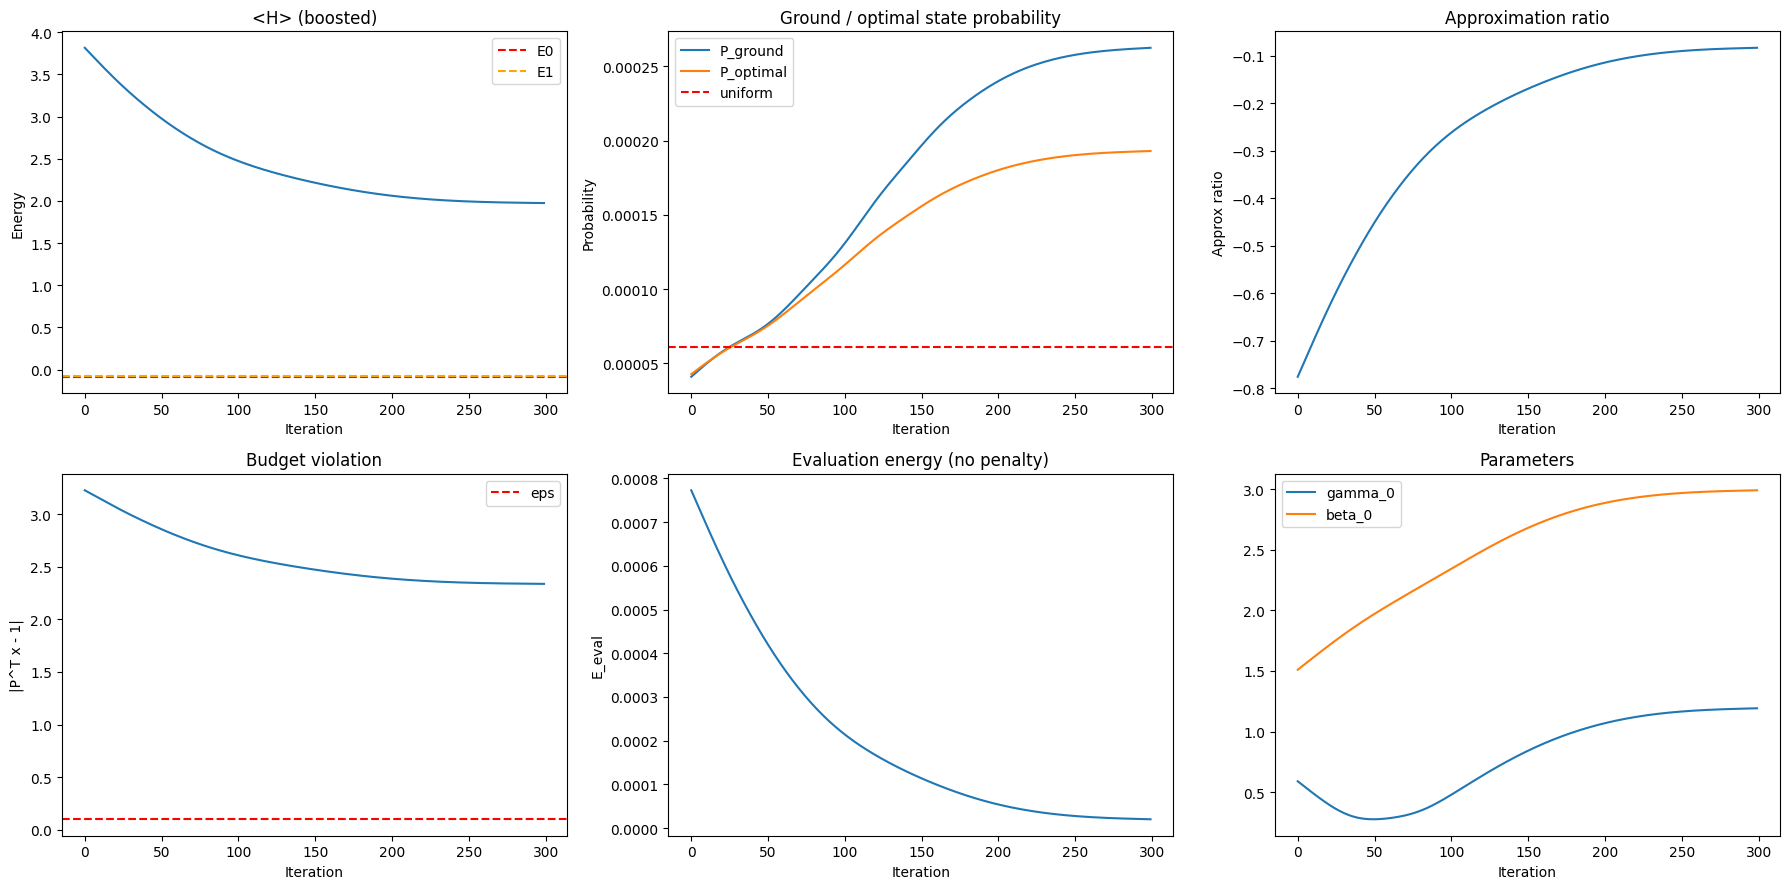

In [63]:
plt.figure(figsize=(18, 9))

plt.subplot(2, 3, 1)
plt.plot(history[:, 0] * hamiltonian_boost)
plt.axhline(y=E0, color="r", linestyle="--", label="E0")
plt.axhline(y=E1, color="orange", linestyle="--", label="E1")
plt.xlabel("Iteration"); plt.ylabel("Energy"); plt.title("<H> (boosted)"); plt.legend()

plt.subplot(2, 3, 2)
plt.plot(history[:, 3], label="P_ground")
plt.plot(history[:, 4], label="P_optimal")
plt.axhline(y=1 / dim, color="r", linestyle="--", label="uniform")
plt.xlabel("Iteration"); plt.ylabel("Probability"); plt.title("Ground / optimal state probability"); plt.legend()

plt.subplot(2, 3, 3)
plt.plot(history[:, 5])
plt.xlabel("Iteration"); plt.ylabel("Approx ratio"); plt.title("Approximation ratio")

plt.subplot(2, 3, 4)
plt.plot(np.sqrt(np.maximum(history[:, 2], 0.0) / lamb))
plt.axhline(y=eps, color="r", linestyle="--", label="eps")
plt.xlabel("Iteration"); plt.ylabel("|P^T x - 1|"); plt.title("Budget violation"); plt.legend()

plt.subplot(2, 3, 5)
plt.plot(history[:, 1])
plt.xlabel("Iteration"); plt.ylabel("E_eval"); plt.title("Evaluation energy (no penalty)")

plt.subplot(2, 3, 6)
plt.plot(history[:, 6], label="gamma_0")
plt.plot(history[:, 7], label="beta_0")
plt.xlabel("Iteration"); plt.title("Parameters"); plt.legend()

plt.tight_layout()
plt.show()

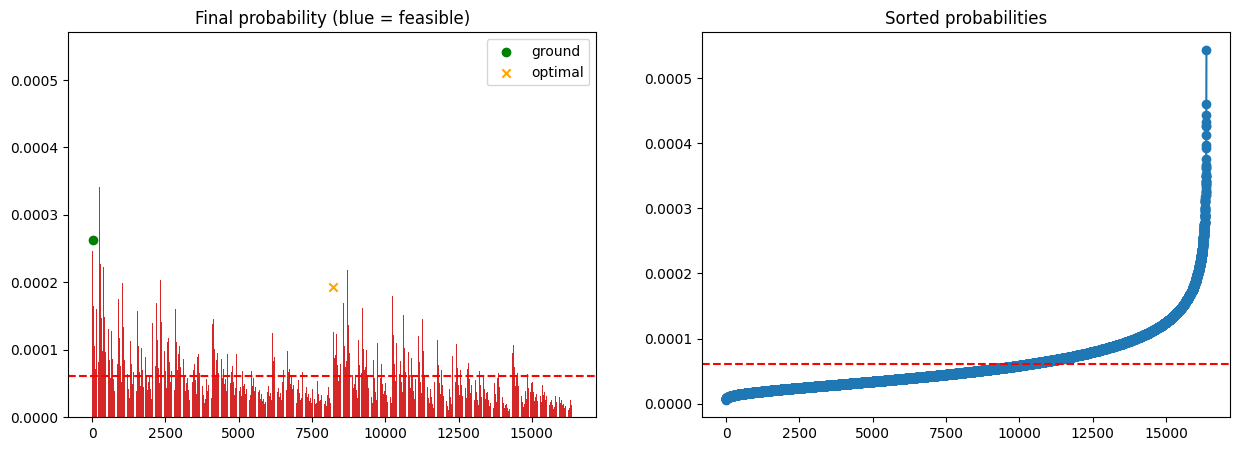

In [64]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
colors = np.where(np.isin(np.arange(dim), idx_feasible), "tab:blue", "tab:red")
plt.bar(np.arange(dim), prob, color=colors)
plt.scatter(idx_ground, prob[idx_ground], color="green", zorder=3, label="ground")
plt.scatter([idx_optimal], [prob[idx_optimal]], color="orange", marker="x", zorder=3, label="optimal")
plt.axhline(y=1 / dim, color="r", linestyle="--")
plt.title("Final probability (blue = feasible)"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(sorted(prob), marker="o")
plt.axhline(y=1 / dim, color="r", linestyle="--")
plt.title("Sorted probabilities")
plt.show()

In [65]:
assert False

AssertionError: 

# Method Comparison

Reuses the cached results written by `run()` (each config is optimized only if it has no saved run).

gradient vs McLachlan (diagonalize / tikhonov), each McLachlan variant with the global-phase correction on (solid) and off (dashed, `_noPC`),
plus the linear ramp (rampB) at `RAMP_LAYERS` as level lines (one circuit each, no iterations).


[gradient] loaded A7_p5_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_gradient_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[mcLachlan_diagonalize] loaded A7_p5_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_diagonalize_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[mcLachlan_diagonalize_noPC] loaded A7_p5_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_diagonalize_noPC_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[mcLachlan_tikhonov] loaded A7_p5_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_tikhonov_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[mcLachlan_tikhonov_noPC] loaded A7_p5_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_tikhonov_noPC_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[rampB0.2_3.0] loaded A7_p50_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_rampB0.2_3.0_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[rampB0.2_3.0] loaded A7_p100_E0_S0 from experiment/exp_Q2_L0.005_q1.

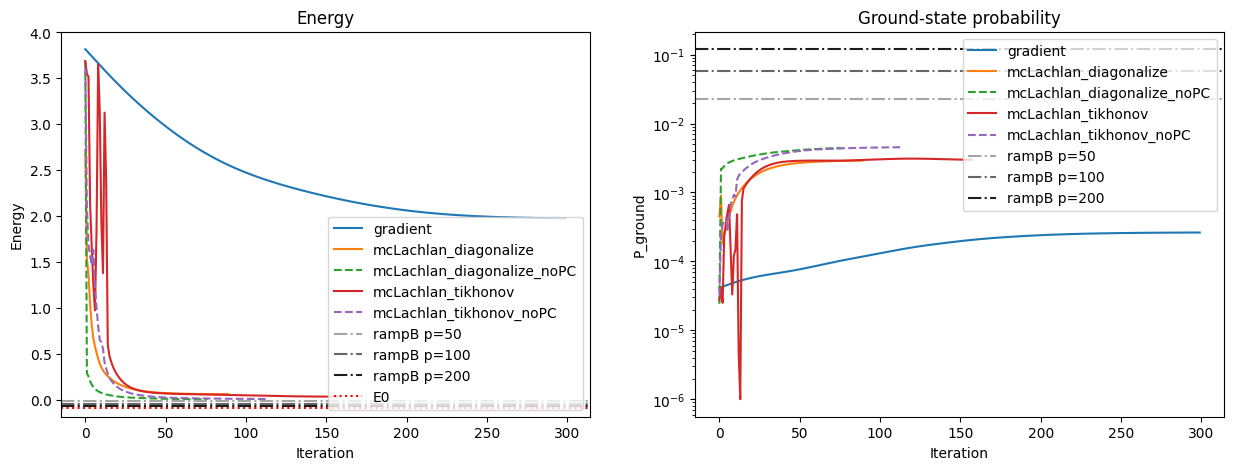

In [ ]:
compare_configs = [("gradient", None, None),
                   ("mcLachlan", "diagonalize", True), ("mcLachlan", "diagonalize", False),
                   ("mcLachlan", "tikhonov", True), ("mcLachlan", "tikhonov", False)]
runs = {}
for method, inv, pc in compare_configs:
    r = run(method=method, inverse=inv, phase_correction=pc, overwrite=False)
    runs[r["tag"]] = r
ramp_runs = {f"rampB p={p}": run(method="ramp", layer=p, overwrite=False) for p in RAMP_LAYERS}   # one circuit each

rows = [[name, r["history"][-1, 0] * hamiltonian_boost, r["history"][-1, 3], r["history"][-1, 5],
         r["num_iter"], r["optim_time"], r["iter_times"].mean() * 1e3, r["loaded"]]
        for name, r in {**runs, **ramp_runs}.items()]
print(pd.DataFrame(rows, columns=["Run", "Energy", "Prob_Ground", "Approx_ratio", "epochs", "time_s", "iter_ms", "cached"]))

ramp_colors = plt.cm.Greys(np.linspace(0.45, 0.9, len(ramp_runs)))
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for name, r in runs.items():
    plt.plot(r["history"][:, 0] * hamiltonian_boost, "--" if name.endswith("_noPC") else "-", label=name)
for (name, r), c in zip(ramp_runs.items(), ramp_colors):
    plt.axhline(y=r["history"][-1, 0] * hamiltonian_boost, color=c, linestyle="-.", label=name)
plt.axhline(y=E0, color="r", linestyle=":", label="E0")
plt.xlabel("Iteration"); plt.ylabel("Energy"); plt.title("Energy"); plt.legend()

plt.subplot(1, 2, 2)
for name, r in runs.items():
    plt.plot(r["history"][:, 3], "--" if name.endswith("_noPC") else "-", label=name)
for (name, r), c in zip(ramp_runs.items(), ramp_colors):
    plt.axhline(y=r["history"][-1, 3], color=c, linestyle="-.", label=name)
plt.yscale("log"); plt.xlabel("Iteration"); plt.ylabel("P_ground"); plt.title("Ground-state probability"); plt.legend()
plt.show()


# Phase Correction (McLachlan)

Effect of the global-phase (Fubini–Study) term in the metric:
$A_{ij} = \mathrm{Re}\langle\partial_i\psi|\partial_j\psi\rangle - \underbrace{\mathrm{Re}\big(\langle\partial_i\psi|\psi\rangle\langle\psi|\partial_j\psi\rangle\big)}_{\text{PHASE\_CORRECTION}}$

Left: McLachlan + diagonalize, right: McLachlan + tikhonov; solid = correction on, dashed = off.
Runs are cached as `mcLachlan_{inverse}` / `mcLachlan_{inverse}_noPC` and executed one after another.


E 0.000832, E_eval -0.000544, P_gs 0.0029:  30%|██▉       | 89/300 [00:02<00:05, 37.11it/s]


[mcLachlan_diagonalize] saved A7_p5_E0_S0 to experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_diagonalize_Ramp_boost_Jh.npz


E 0.000079, E_eval -0.000586, P_gs 0.0044:  25%|██▌       | 76/300 [00:02<00:06, 35.24it/s]


[mcLachlan_diagonalize_noPC] saved A7_p5_E0_S0 to experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_diagonalize_noPC_Ramp_boost_Jh.npz


E 0.000460, E_eval -0.000538, P_gs 0.0030:  52%|█████▏    | 157/300 [00:04<00:03, 36.37it/s]


[mcLachlan_tikhonov] saved A7_p5_E0_S0 to experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_tikhonov_Ramp_boost_Jh.npz


E 0.000108, E_eval -0.000601, P_gs 0.0045:  38%|███▊      | 113/300 [00:03<00:05, 36.50it/s]


[mcLachlan_tikhonov_noPC] saved A7_p5_E0_S0 to experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_tikhonov_noPC_Ramp_boost_Jh.npz
       Inverse  Phase_Corr    Energy  Prob_Ground  Approx_ratio  epochs    time_s    iter_ms  cached
0  diagonalize        True  0.060047     0.002894      0.435722      90  2.409834  26.132362   False
1  diagonalize       False  0.005626     0.004400      0.474675      77  2.171918  26.908104   False
2     tikhonov        True  0.033121     0.002969      0.430311     158  4.332430  26.209407   False
3     tikhonov       False  0.007731     0.004528      0.487846     114  3.116133  26.473917   False


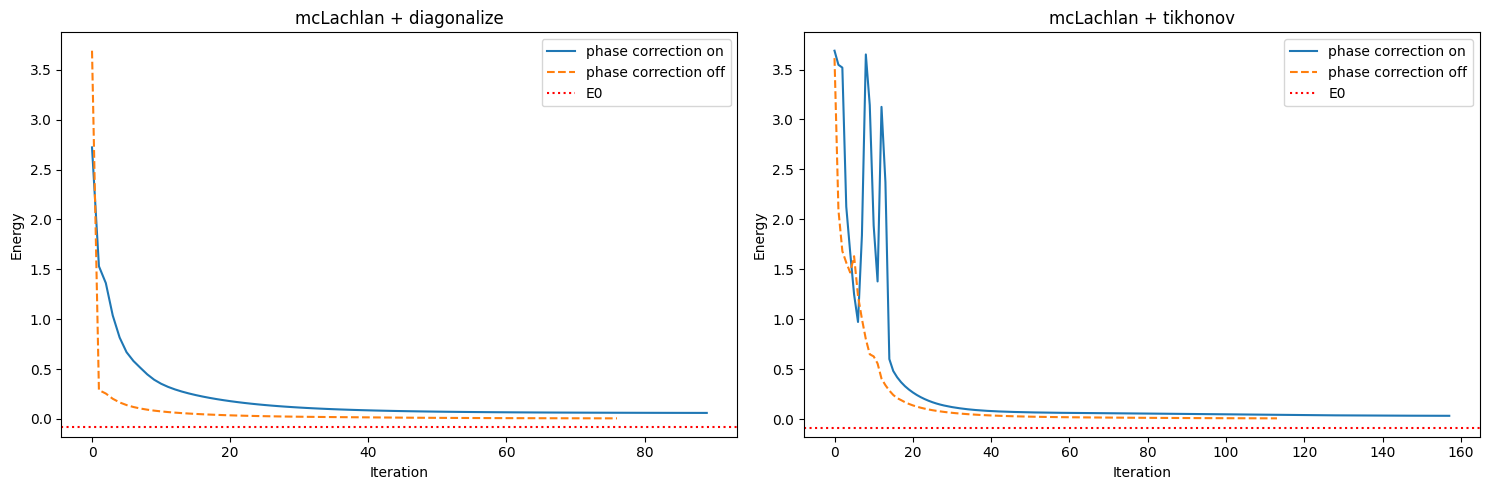

In [ ]:
pc_configs = [("diagonalize", True), ("diagonalize", False), ("tikhonov", True), ("tikhonov", False)]
pc_runs = {}
for inv, pc in pc_configs:
    pc_runs[(inv, pc)] = run(method="mcLachlan", inverse=inv, phase_correction=pc, overwrite=False)

rows = [[inv, pc, r["history"][-1, 0] * hamiltonian_boost, r["history"][-1, 3], r["history"][-1, 5],
         r["num_iter"], r["optim_time"], r["iter_times"].mean() * 1e3, r["loaded"]]
        for (inv, pc), r in pc_runs.items()]
print(pd.DataFrame(rows, columns=["Inverse", "Phase_Corr", "Energy", "Prob_Ground", "Approx_ratio", "epochs", "time_s", "iter_ms", "cached"]))

plt.figure(figsize=(15, 5))
for k, inv in enumerate(["diagonalize", "tikhonov"]):
    plt.subplot(1, 2, k + 1)
    for pc, ls in [(True, "-"), (False, "--")]:
        r = pc_runs[(inv, pc)]
        plt.plot(r["history"][:, 0] * hamiltonian_boost, ls, label=f"phase correction {'on' if pc else 'off'}")
    plt.axhline(y=E0, color="r", linestyle=":", label="E0")
    plt.xlabel("Iteration"); plt.ylabel("Energy"); plt.title(f"mcLachlan + {inv}"); plt.legend()
plt.tight_layout()
plt.show()


# Linear Ramp Scan

rampB at `RAMP_LAYERS` (one circuit each) against the optimized $p = 5$ runs.


[rampB0.2_3.0] loaded A7_p50_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_rampB0.2_3.0_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[rampB0.2_3.0] loaded A7_p100_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_rampB0.2_3.0_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[rampB0.2_3.0] loaded A7_p200_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_rampB0.2_3.0_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[gradient] loaded A7_p5_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_gradient_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[mcLachlan_tikhonov] loaded A7_p5_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_tikhonov_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
[mcLachlan_tikhonov_noPC] loaded A7_p5_E0_S0 from experiment/exp_Q2_L0.005_q1.5/expectation_mcLachlan_tikhonov_noPC_Ramp_boost_Jh.npz (pass overwrite=True to rerun)
                           Run    p    Energy       Gap  Prob_Ground  Approx_ratio       time_ms  cached
0     

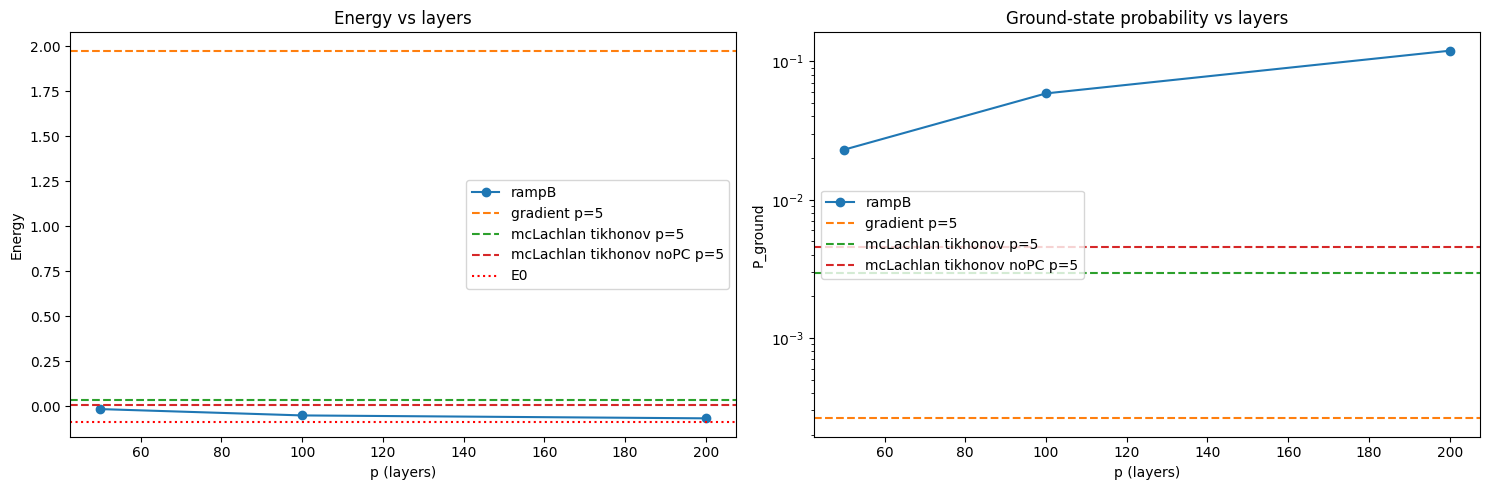

In [ ]:
ramp_scan = {p: run(method="ramp", layer=p, overwrite=False) for p in RAMP_LAYERS}
ref_runs = {"gradient p=5": run(method="gradient", overwrite=False),
            "mcLachlan tikhonov p=5": run(method="mcLachlan", inverse="tikhonov", phase_correction=True, overwrite=False),
            "mcLachlan tikhonov noPC p=5": run(method="mcLachlan", inverse="tikhonov", phase_correction=False, overwrite=False)}

rows = [[r["tag"], p, r["history"][-1, 0] * hamiltonian_boost, r["history"][-1, 0] * hamiltonian_boost - E0, r["history"][-1, 3], r["history"][-1, 5], r["iter_times"][0] * 1e3, r["loaded"]]
        for p, r in ramp_scan.items()]
rows += [[name, LAYER, r["history"][-1, 0] * hamiltonian_boost, r["history"][-1, 0] * hamiltonian_boost - E0, r["history"][-1, 3], r["history"][-1, 5], r["optim_time"] * 1e3, r["loaded"]]
         for name, r in ref_runs.items()]
print(pd.DataFrame(rows, columns=["Run", "p", "Energy", "Gap", "Prob_Ground", "Approx_ratio", "time_ms", "cached"]))

plt.figure(figsize=(15, 5))
for k, (col, ylabel, title) in enumerate([(0, "Energy", "Energy vs layers"), (3, "P_ground", "Ground-state probability vs layers")]):
    plt.subplot(1, 2, k + 1)
    scale = hamiltonian_boost if col == 0 else 1.0
    plt.plot(RAMP_LAYERS, [ramp_scan[p]["history"][-1, col] * scale for p in RAMP_LAYERS], "o-", label="rampB")
    for j, (name, r) in enumerate(ref_runs.items()):
        plt.axhline(y=r["history"][-1, col] * scale, color=f"C{j + 1}", linestyle="--", label=name)
    if col == 0:
        plt.axhline(y=E0, color="r", linestyle=":", label="E0")
    else:
        plt.yscale("log")
    plt.xlabel("p (layers)"); plt.ylabel(ylabel); plt.title(title); plt.legend(loc="center left" if col else "best")
plt.tight_layout()
plt.show()
